# Case Studies in Data Science – Task 1 Analysis

## Dataset 1: Bank Transactions

### 1. Initial Data Inspection

In [1]:
import pandas as pd

df1 = pd.read_csv("Datasets/bank_transactions_data_2.csv")

In [2]:
df1.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [3]:
df1.shape

(2512, 16)

In [4]:
df1.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

### 2. Data Quality Checks

In [6]:
df1.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [7]:
df1.duplicated().sum()

np.int64(0)

In [8]:
df1.nunique()

TransactionID              2512
AccountID                   495
TransactionAmount          2455
TransactionDate            2512
TransactionType               2
Location                     43
DeviceID                    681
IP Address                  592
MerchantID                  100
Channel                       3
CustomerAge                  63
CustomerOccupation            4
TransactionDuration         288
LoginAttempts                 5
AccountBalance             2510
PreviousTransactionDate     360
dtype: int64

### 3. Target Variable Inspection: Channel

In [9]:
df1["Channel"].value_counts()

Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64

In [10]:
df1["Channel"].value_counts(normalize=True) * 100

Channel
Branch    34.554140
ATM       33.160828
Online    32.285032
Name: proportion, dtype: float64

Observation:
- Channel has three classes: Branch, ATM and Online.
- The classes appear approximately balanced.
- Therefore severe class imbalance is unlikely to be a major issue for this target.

### 4. Date Variable Investigation

In [11]:
df1_work = df1.copy()

In [12]:
df1_work["TransactionDate"] = pd.to_datetime(df1_work["TransactionDate"])
df1_work["PreviousTransactionDate"] = pd.to_datetime(df1_work["PreviousTransactionDate"])

In [13]:
print("Transaction Date:")
print(df1_work["TransactionDate"].min())
print(df1_work["TransactionDate"].max())

print("\nPrevious Transaction Date:")
print(df1_work["PreviousTransactionDate"].min())
print(df1_work["PreviousTransactionDate"].max())

Transaction Date:
2023-01-02 16:00:06
2024-01-01 18:21:50

Previous Transaction Date:
2024-11-04 08:06:23
2024-11-04 08:12:23


In [14]:
(df1_work["PreviousTransactionDate"] > df1_work["TransactionDate"]).sum()

np.int64(2512)

Observation:
- PreviousTransactionDate appears inconsistent with TransactionDate.
- All records have a "previous" transaction date later than the current transaction.
- This variable should be investigated before deciding whether to use it for modelling.

In [15]:
df1_work[
    [
        "TransactionAmount",
        "CustomerAge",
        "TransactionDuration",
        "LoginAttempts",
        "AccountBalance"
    ]
].describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [16]:
for col in [
    "TransactionType",
    "CustomerOccupation",
    "Location",
    "MerchantID"
]:
    print("\n", col)
    print(df1_work[col].value_counts())


 TransactionType
TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64

 CustomerOccupation
CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64

 Location
Location
Fort Worth          70
Los Angeles         69
Oklahoma City       68
Charlotte           68
Tucson              67
Philadelphia        67
Omaha               65
Miami               64
Detroit             63
Houston             63
Memphis             63
Denver              62
Kansas City         61
Boston              61
Mesa                61
Atlanta             61
Seattle             61
Colorado Springs    60
Jacksonville        60
Fresno              60
Chicago             60
Austin              59
San Jose            59
Raleigh             59
San Antonio         59
San Diego           59
Indianapolis        58
New York            58
San Francisco       57
Nashville           55
Milwaukee           55
Las Vegas           55
Virginia Beach      55
P

### 5. Preliminary Relationships with Channel

In [17]:
pd.crosstab(
    df1_work["TransactionType"],
    df1_work["Channel"]
)

Channel,ATM,Branch,Online
TransactionType,,,
Credit,73,251,244
Debit,760,617,567


In [18]:
pd.crosstab(
    df1_work["TransactionType"],
    df1_work["Channel"],
    normalize="index"
) * 100

Channel,ATM,Branch,Online
TransactionType,,,
Credit,12.852113,44.190141,42.957746
Debit,39.094650,31.738683,29.166667


In [19]:
df1_work.groupby("Channel")[
    [
        "TransactionAmount",
        "CustomerAge",
        "TransactionDuration",
        "LoginAttempts",
        "AccountBalance"
    ]
].mean().round(2)

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
Channel,,,,,
ATM,307.72,44.96,122.09,1.12,5030.52
Branch,288.23,44.63,116.68,1.12,5202.26
Online,297.21,44.43,120.31,1.13,5106.22


Observation:
- Transaction type appears to have some association with channel.
- Credit transactions have a lower ATM proportion than debit transactions.
- TransactionType may therefore provide useful predictive information.

## Analysis Decision Log

### Decision 1: Fraud prediction
Initial idea:
Use Dataset 1 for fraud detection.

Issue found:
The dataset does not contain a fraud-labelled target.

Current decision:
Investigate Channel as the target instead.

---

### Decision 2: PreviousTransactionDate
Issue found:
The supposed previous transaction dates occur after the current transaction dates.

Current status:
Investigate/exclude before modelling.

## 6. Visual Exploratory Data Analysis

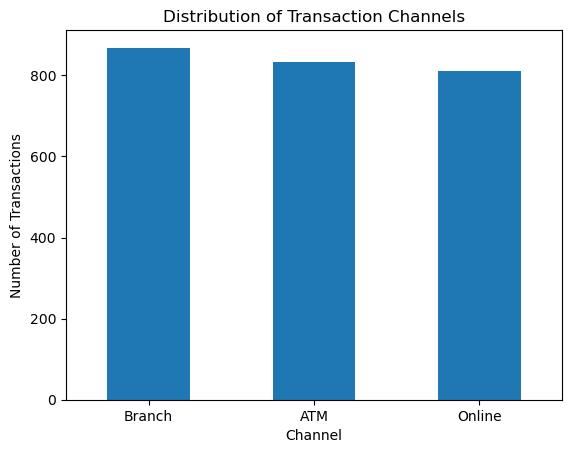

In [20]:
import matplotlib.pyplot as plt

df1_work["Channel"].value_counts().plot(kind="bar")

plt.title("Distribution of Transaction Channels")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

Observation:
- The three Channel classes are distributed fairly evenly.
- No major class imbalance is visible.
- This supports using Channel as a classification target without requiring major class-balancing techniques at this stage.

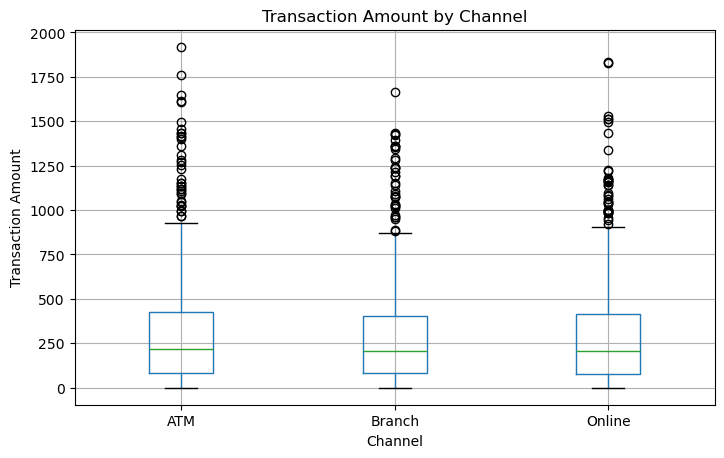

In [21]:
df1_work.boxplot(
    column="TransactionAmount",
    by="Channel",
    figsize=(8, 5)
)

plt.title("Transaction Amount by Channel")
plt.suptitle("")
plt.xlabel("Channel")
plt.ylabel("Transaction Amount")
plt.show()

Observation:
- Transaction amounts overlap substantially across ATM, Branch and Online transactions.
- There may be small differences in their distributions, but TransactionAmount alone does not appear to clearly separate the channels.

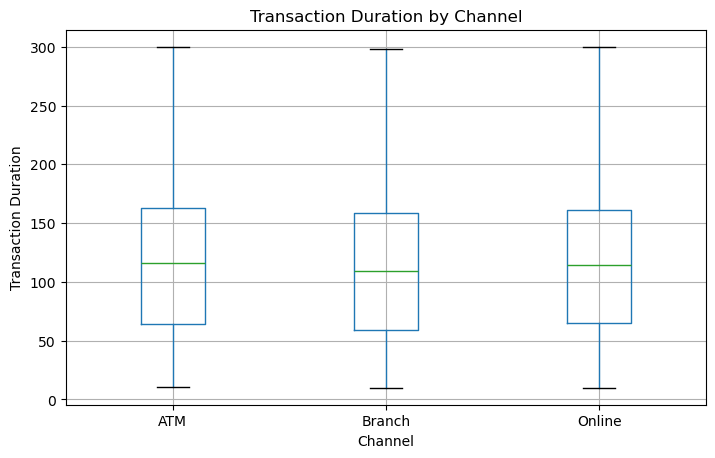

In [22]:
df1_work.boxplot(
    column="TransactionDuration",
    by="Channel",
    figsize=(8, 5)
)

plt.title("Transaction Duration by Channel")
plt.suptitle("")
plt.xlabel("Channel")
plt.ylabel("Transaction Duration")
plt.show()

Observation:
- Transaction-duration distributions show considerable overlap across the three channels.
- The differences between channel groups appear relatively small.
- TransactionDuration may contribute some information but is unlikely to be a strong predictor by itself.

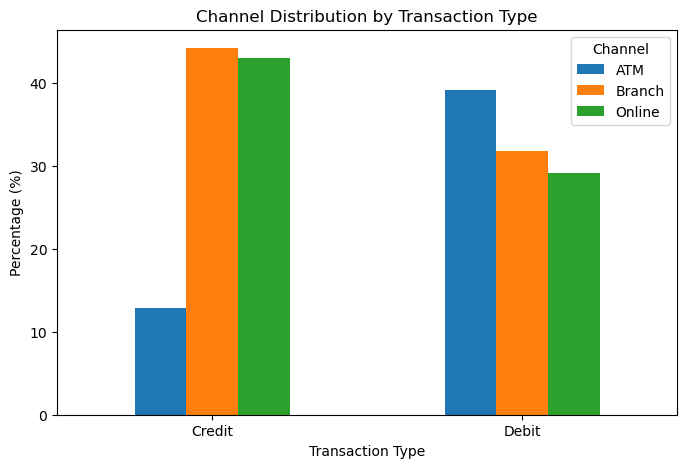

In [23]:
transaction_channel = pd.crosstab(
    df1_work["TransactionType"],
    df1_work["Channel"],
    normalize="index"
) * 100

transaction_channel.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Channel Distribution by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Channel")
plt.show()

Observation:
- Channel usage differs more noticeably between Debit and Credit transactions.
- ATM usage is considerably more common among Debit transactions than Credit transactions.
- TransactionType therefore appears to contain useful information for predicting Channel.

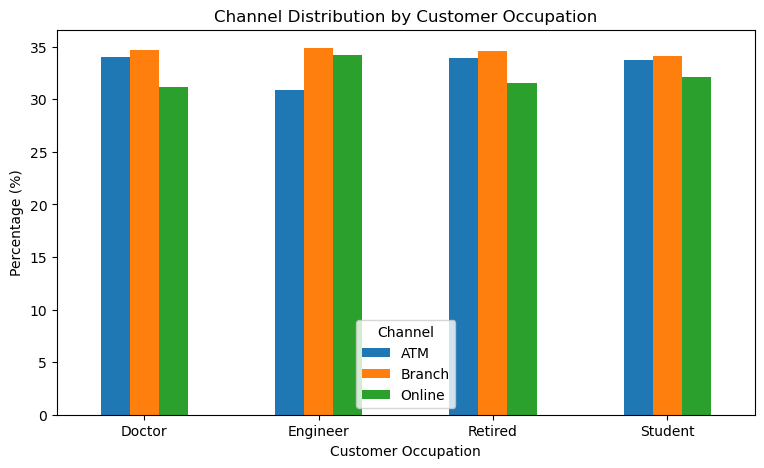

In [24]:
occupation_channel = pd.crosstab(
    df1_work["CustomerOccupation"],
    df1_work["Channel"],
    normalize="index"
) * 100

occupation_channel.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Channel Distribution by Customer Occupation")
plt.xlabel("Customer Occupation")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Channel")
plt.show()

Observation:
- Channel proportions are relatively similar across the occupation groups.
- CustomerOccupation does not show a strong visual separation of banking-channel preferences.
- It may still contribute some information when combined with other features.

In [25]:
df1_work["Hour"] = df1_work["TransactionDate"].dt.hour
df1_work["DayOfWeek"] = df1_work["TransactionDate"].dt.day_name()
df1_work["Month"] = df1_work["TransactionDate"].dt.month
df1_work["IsWeekend"] = df1_work["TransactionDate"].dt.dayofweek >= 5

In [26]:
print("Hour:")
print(df1_work["Hour"].value_counts().sort_index())

print("\nDay of Week:")
print(df1_work["DayOfWeek"].value_counts())

print("\nMonth:")
print(df1_work["Month"].value_counts().sort_index())

print("\nWeekend:")
print(df1_work["IsWeekend"].value_counts())

Hour:
Hour
16    1316
17     819
18     377
Name: count, dtype: int64

Day of Week:
DayOfWeek
Monday       1070
Friday        373
Thursday      368
Tuesday       360
Wednesday     341
Name: count, dtype: int64

Month:
Month
1     220
2     218
3     197
4     161
5     220
6     212
7     195
8     224
9     214
10    226
11    221
12    204
Name: count, dtype: int64

Weekend:
IsWeekend
False    2512
Name: count, dtype: int64


Observation:
- Transaction times are restricted to only a small number of hours.
- No weekend transactions are present, so IsWeekend is a constant feature and would not be useful for modelling.
- DayOfWeek and Month may still be investigated, but the limited temporal coverage should be treated as a dataset limitation.

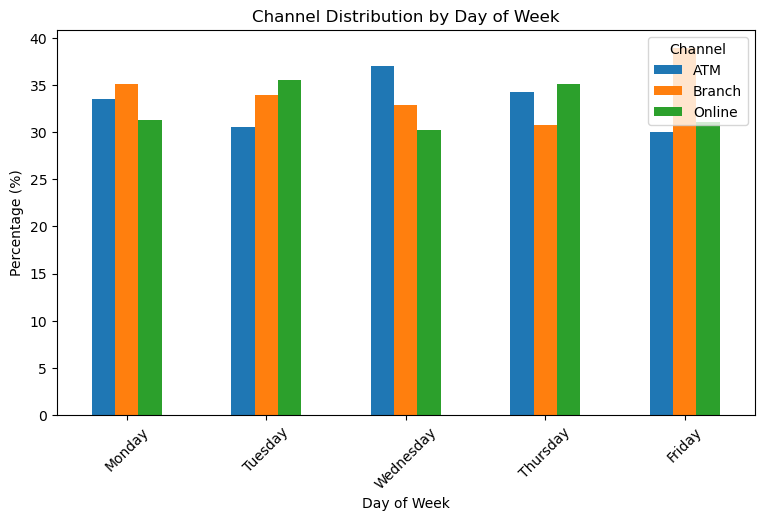

In [27]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

day_channel = pd.crosstab(
    df1_work["DayOfWeek"],
    df1_work["Channel"],
    normalize="index"
) * 100

day_channel = day_channel.reindex(day_order)

day_channel.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Channel Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Channel")
plt.show()

Observation:
- Channel usage varies somewhat across weekdays, although no single channel completely dominates on any day.
- DayOfWeek may contain limited predictive information.
- The uneven number of observations across weekdays should also be considered when interpreting the pattern.

## 7. Feature Selection and Leakage Assessment

In [28]:
candidate_id_cols = [
    "TransactionID",
    "AccountID",
    "DeviceID",
    "IP Address",
    "MerchantID",
    "Location"
]

for col in candidate_id_cols:
    print(f"{col}: {df1_work[col].nunique()} unique values")

TransactionID: 2512 unique values
AccountID: 495 unique values
DeviceID: 681 unique values
IP Address: 592 unique values
MerchantID: 100 unique values
Location: 43 unique values


Observation:
- Several variables have high numbers of unique values and behave more like identifiers than general behavioural features.
- Highly unique identifiers may encourage memorisation rather than generalisable prediction.
- These variables require careful consideration before modelling.

In [29]:
account_counts = df1_work["AccountID"].value_counts()

print(account_counts.describe())
print("\nAccounts with more than one transaction:")
print((account_counts > 1).sum())

count    495.000000
mean       5.074747
std        2.294261
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       12.000000
Name: count, dtype: float64

Accounts with more than one transaction:
471


In [30]:
account_counts.head(10)

AccountID
AC00362    12
AC00363    12
AC00202    12
AC00460    12
AC00257    11
AC00456    11
AC00304    11
AC00480    11
AC00225    11
AC00267    10
Name: count, dtype: int64

Observation:
- Multiple transactions belong to the same accounts.
- A standard random transaction-level train/test split could place records from the same account in both sets.
- This may introduce information leakage or overly optimistic evaluation if account-specific identifiers are used.

In [31]:
channels_per_account = df1_work.groupby("AccountID")["Channel"].nunique()

print(channels_per_account.value_counts().sort_index())

Channel
1     48
2    187
3    260
Name: count, dtype: int64


In [32]:
print("Average number of channels per account:",
      channels_per_account.mean())

Average number of channels per account: 2.4282828282828284


Observation:
- Accounts may appear across one or more transaction channels.
- This suggests that Channel is not necessarily a fixed customer attribute.
- Prediction should therefore focus on transaction/customer characteristics rather than simply memorising AccountID.

### Prediction-time feature review

| Feature | Initial Decision | Reason |
|---|---|---|
| TransactionID | Exclude | Unique transaction identifier |
| AccountID | Exclude from model | Customer identifier; risk of memorisation |
| TransactionAmount | Keep | Transaction characteristic |
| TransactionDate | Transform | Derive interpretable time features |
| TransactionType | Keep | Shows relationship with Channel |
| Location | Investigate | Potential behavioural/contextual information |
| DeviceID | Exclude | High-cardinality identifier |
| IP Address | Exclude | High-cardinality identifier |
| MerchantID | Investigate | May contain behavioural information but has high cardinality |
| CustomerAge | Keep | Customer characteristic |
| CustomerOccupation | Keep | Customer characteristic |
| TransactionDuration | Exclude initially | Only known after/during transaction completion |
| LoginAttempts | Investigate | May represent behaviour but prediction-time availability must be considered |
| AccountBalance | Keep | Customer financial characteristic |
| PreviousTransactionDate | Exclude | Data-quality inconsistency |
| Hour | Investigate | Limited to a narrow time range |
| DayOfWeek | Keep for testing | May contain temporal signal |
| Month | Keep for testing | May contain temporal signal |
| IsWeekend | Exclude | Constant; all records are weekdays |

In [33]:
pd.crosstab(
    df1_work["LoginAttempts"],
    df1_work["Channel"],
    normalize="index"
).round(3) * 100

Channel,ATM,Branch,Online
LoginAttempts,,,
1,33.0,34.7,32.3
2,55.6,33.3,11.1
3,25.8,19.4,54.8
4,37.5,21.9,40.6
5,28.1,50.0,21.9


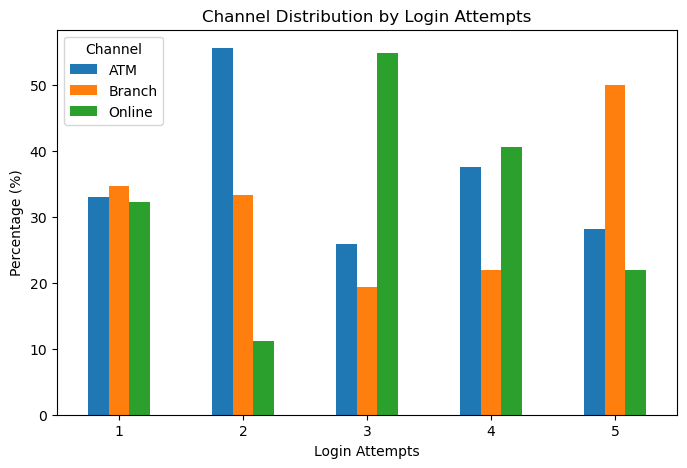

In [34]:
login_channel = pd.crosstab(
    df1_work["LoginAttempts"],
    df1_work["Channel"],
    normalize="index"
) * 100

login_channel.plot(kind="bar", figsize=(8, 5))

plt.title("Channel Distribution by Login Attempts")
plt.xlabel("Login Attempts")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Channel")
plt.show()

Observation:
- Most transactions have only one login attempt.
- Although higher login-attempt groups show different channel proportions, these groups contain very few observations.
- Therefore, the apparent pattern may be unstable and LoginAttempts will not be included in the initial feature set.

In [35]:
location_counts = df1_work["Location"].value_counts()

print(location_counts.describe())
print("\nTop 10 locations:")
print(location_counts.head(10))

count    43.000000
mean     58.418605
std       6.755007
min      41.000000
25%      55.000000
50%      59.000000
75%      62.500000
max      70.000000
Name: count, dtype: float64

Top 10 locations:
Location
Fort Worth       70
Los Angeles      69
Oklahoma City    68
Charlotte        68
Tucson           67
Philadelphia     67
Omaha            65
Miami            64
Detroit          63
Houston          63
Name: count, dtype: int64


In [36]:
location_channel_counts = pd.crosstab(
    df1_work["Location"],
    df1_work["Channel"]
)

location_channel_counts.head(10)

Channel,ATM,Branch,Online
Location,,,
Albuquerque,12,13,16
Atlanta,16,23,22
Austin,11,26,22
Baltimore,20,17,14
Boston,22,17,22
Charlotte,21,23,24
Chicago,18,17,25
Colorado Springs,23,21,16
Columbus,18,18,18


In [37]:
merchant_counts = df1_work["MerchantID"].value_counts()

print(merchant_counts.describe())
print("\nTop 10 merchants:")
print(merchant_counts.head(10))

count    100.000000
mean      25.120000
std        5.065789
min       13.000000
25%       22.000000
50%       25.000000
75%       28.250000
max       45.000000
Name: count, dtype: float64

Top 10 merchants:
MerchantID
M026    45
M066    34
M065    33
M013    33
M014    33
M028    33
M068    32
M001    32
M070    32
M005    32
Name: count, dtype: int64


In [38]:
pd.crosstab(
    df1_work["MerchantID"],
    df1_work["Channel"]
).head(10)

Channel,ATM,Branch,Online
MerchantID,,,
M001,12,9,11
M002,6,15,10
M003,11,7,8
M004,11,12,8
M005,9,13,10
M006,6,3,7
M007,7,11,11
M008,6,10,5
M009,13,10,7


In [39]:
preliminary_features = [
    "TransactionAmount",
    "TransactionType",
    "CustomerAge",
    "CustomerOccupation",
    "AccountBalance",
    "DayOfWeek",
    "Month"
]

target = "Channel"

print("Preliminary features:")
print(preliminary_features)
print("\nTarget:", target)

Preliminary features:
['TransactionAmount', 'TransactionType', 'CustomerAge', 'CustomerOccupation', 'AccountBalance', 'DayOfWeek', 'Month']

Target: Channel


Observation:
- Identifier-like and inconsistent variables were excluded from the preliminary feature set.
- The initial features focus on interpretable customer, transaction and temporal characteristics.
- Additional variables may be reconsidered if EDA provides a clear justification for their inclusion.

### Decision 3: Identifier variables

Issue:
Several variables behave primarily as identifiers and may encourage memorisation.

Decision:
Exclude direct identifiers such as TransactionID, AccountID, DeviceID and IP Address from the initial model.

---

### Decision 4: Weekend feature

Issue:
No weekend transactions exist in Dataset 1.

Decision:
Exclude IsWeekend because it contains no variation and therefore cannot provide predictive information.

## 8. Data Preparation for Modelling

In [40]:
features_d1 = [
    "TransactionAmount",
    "TransactionType",
    "CustomerAge",
    "CustomerOccupation",
    "AccountBalance",
    "DayOfWeek",
    "Month",
    "Hour"
]

target_d1 = "Channel"

X = df1_work[features_d1]
y = df1_work[target_d1]

print("Features:", features_d1)
print("Target:", target_d1)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['TransactionAmount', 'TransactionType', 'CustomerAge', 'CustomerOccupation', 'AccountBalance', 'DayOfWeek', 'Month', 'Hour']
Target: Channel
X shape: (2512, 8)
y shape: (2512,)


Observation:
- The modelling features focus on interpretable transaction, customer and temporal characteristics.
- Direct identifiers, inconsistent variables and very sparse behavioural variables were excluded.

In [41]:
from sklearn.model_selection import GroupShuffleSplit

groups = df1_work["AccountID"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nUnique training accounts:",
      df1_work.iloc[train_idx]["AccountID"].nunique())

print("Unique test accounts:",
      df1_work.iloc[test_idx]["AccountID"].nunique())

Training rows: 1991
Test rows: 521

Unique training accounts: 396
Unique test accounts: 99


In [42]:
train_accounts = set(df1_work.iloc[train_idx]["AccountID"])
test_accounts = set(df1_work.iloc[test_idx]["AccountID"])

print("Accounts appearing in both sets:",
      len(train_accounts.intersection(test_accounts)))

Accounts appearing in both sets: 0


Observation:
- The data was split by AccountID rather than by individual transactions.
- No account appears in both the training and test sets.
- This provides a more realistic evaluation of how the model generalises to transactions from unseen accounts.

In [43]:
print("Training target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training target distribution:
Channel
Branch    34.71
ATM       34.05
Online    31.24
Name: proportion, dtype: float64

Test target distribution:
Channel
Online    36.28
Branch    33.97
ATM       29.75
Name: proportion, dtype: float64


In [44]:
numeric_features = [
    "TransactionAmount",
    "CustomerAge",
    "AccountBalance",
    "Month",
    "Hour"
]

categorical_features = [
    "TransactionType",
    "CustomerOccupation",
    "DayOfWeek"
]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['TransactionAmount', 'CustomerAge', 'AccountBalance', 'Month', 'Hour']
Categorical features: ['TransactionType', 'CustomerOccupation', 'DayOfWeek']


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_features),
        ("numerical",
         "passthrough",
         numeric_features)
    ]
)

preprocessor

,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [46]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="macro"
)

print("Baseline Accuracy:", round(baseline_accuracy, 3))
print("Baseline Macro F1:", round(baseline_f1, 3))

Baseline Accuracy: 0.34
Baseline Macro F1: 0.169


Observation:
- The most-frequent-class baseline achieved an accuracy of 0.340 and a Macro F1-score of 0.169.
- The baseline provides a reference point for evaluating whether the machine learning model learns useful patterns beyond simply predicting the most common class.

## 9. Decision Tree Classification

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone

decision_tree_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

decision_tree_model.fit(X_train, y_train)

dt_train_predictions = decision_tree_model.predict(X_train)
dt_test_predictions = decision_tree_model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score, f1_score

dt_train_accuracy = accuracy_score(y_train, dt_train_predictions)
dt_test_accuracy = accuracy_score(y_test, dt_test_predictions)

dt_train_f1 = f1_score(
    y_train,
    dt_train_predictions,
    average="macro"
)

dt_test_f1 = f1_score(
    y_test,
    dt_test_predictions,
    average="macro"
)

print("Baseline Accuracy:", round(baseline_accuracy, 3))
print("Baseline Macro F1:", round(baseline_f1, 3))

print("\nDecision Tree Training Accuracy:", round(dt_train_accuracy, 3))
print("Decision Tree Test Accuracy:", round(dt_test_accuracy, 3))

print("\nDecision Tree Training Macro F1:", round(dt_train_f1, 3))
print("Decision Tree Test Macro F1:", round(dt_test_f1, 3))

Baseline Accuracy: 0.34
Baseline Macro F1: 0.169

Decision Tree Training Accuracy: 1.0
Decision Tree Test Accuracy: 0.361

Decision Tree Training Macro F1: 1.0
Decision Tree Test Macro F1: 0.362


Observation:
- The Decision Tree achieved a test accuracy of 0.361 and a Macro F1-score of 0.362, compared with the baseline accuracy of 0.340.
- Training accuracy and Macro F1 were both 1.000, while test performance was much lower.
- This suggests substantial overfitting, as the model learned the training data extremely well but generalised poorly to unseen accounts.
- The small improvement in test accuracy over the baseline also suggests that the selected features provide only limited predictive signal for Channel in the current unrestricted Decision Tree.

In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        dt_test_predictions,
        digits=3
    )
)

              precision    recall  f1-score   support

         ATM      0.360     0.413     0.384       155
      Branch      0.371     0.356     0.363       177
      Online      0.353     0.323     0.337       189

    accuracy                          0.361       521
   macro avg      0.361     0.364     0.362       521
weighted avg      0.361     0.361     0.360       521



Observation:
- The tuned model identifies ATM transactions considerably better than Branch or Online transactions, achieving an ATM recall of 0.613.
- Recall is much lower for Branch (0.271) and Online (0.265), showing that many transactions from these two channels are misclassified.
- Tuning therefore reduced overfitting, but it did not make the three channels equally distinguishable.
- The result suggests that the available customer, transaction and temporal features contain stronger information for identifying ATM usage than for separating Branch and Online behaviour.

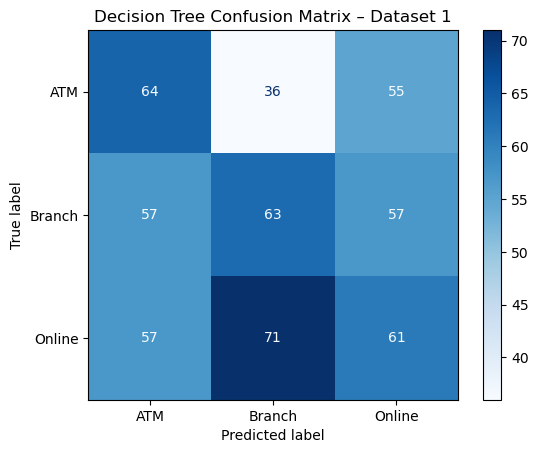

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_test_predictions,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix – Dataset 1")
plt.show()

Observation:
- The Decision Tree identifies ATM transactions most effectively, with 64 of 155 ATM transactions correctly classified and the highest recall among the three classes.
- The greatest confusion occurs between Online and Branch transactions, particularly with 71 Online transactions incorrectly predicted as Branch.
- Branch and Online transactions are also frequently confused with ATM transactions.
- Overall, the confusion matrix indicates that the selected customer and transaction features do not clearly distinguish the three banking channels.

In [51]:
tree_classifier = decision_tree_model.named_steps["classifier"]

print("Tree depth:", tree_classifier.get_depth())
print("Number of leaves:", tree_classifier.get_n_leaves())

Tree depth: 33
Number of leaves: 793


In [52]:
import pandas as pd

fitted_preprocessor = decision_tree_model.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
11,numerical__TransactionAmount,0.238615
13,numerical__AccountBalance,0.223533
12,numerical__CustomerAge,0.175433
14,numerical__Month,0.133676
15,numerical__Hour,0.045138
7,categorical__DayOfWeek_Monday,0.032044
0,categorical__TransactionType_Credit,0.028038
3,categorical__CustomerOccupation_Engineer,0.027682
8,categorical__DayOfWeek_Thursday,0.021068
2,categorical__CustomerOccupation_Doctor,0.018863


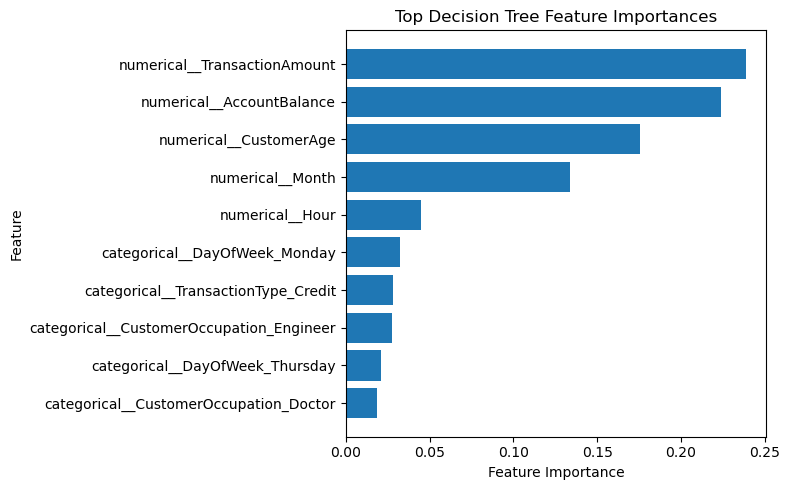

In [53]:
top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Observation:
- The Decision Tree places the greatest importance on TransactionAmount, followed by AccountBalance, CustomerAge and Month.
- TransactionType does appear among the top predictors, but its importance is relatively low compared with the main numerical features.
- This is interesting because the earlier EDA showed an association between TransactionType and Channel, while the fitted Decision Tree relies more heavily on continuous financial and customer characteristics when considering all features together.
- Feature importance indicates which variables the model used most for splitting the data, but it does not imply that these variables cause customers to choose a particular banking channel.

### Evaluation metric rationale

Accuracy is used because Channel has three approximately balanced classes and provides an intuitive measure of overall classification performance.

Macro F1 is also considered because it evaluates performance across ATM, Branch and Online equally rather than allowing performance on one class to dominate the overall result.

The confusion matrix is used to examine which specific channels are being confused by the model.

## 10. Decision Tree Tuning and Pruning

In [54]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone

train_groups = df1_work.iloc[train_idx]["AccountID"]

tuned_tree_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "classifier__max_depth": [3, 5, 7, 10],
    "classifier__min_samples_split": [10, 20, 50],
    "classifier__min_samples_leaf": [5, 10, 20],
    "classifier__criterion": ["gini", "entropy"]
}

group_cv = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=tuned_tree_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=group_cv,
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train,
    groups=train_groups
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(round(grid_search.best_score_, 3))

Best parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 50}

Best cross-validation Macro F1:
0.367


Observation:
- Group-aware cross-validation was used to tune the Decision Tree while keeping transactions from the same account within the same fold.
- The best-performing configuration used the Gini criterion, a maximum depth of 10, a minimum of 5 samples per leaf, and a minimum of 50 samples required to split a node.
- The best cross-validation Macro F1-score was 0.367.
- Restricting the tree complexity was investigated to reduce the substantial overfitting observed in the unrestricted Decision Tree.

In [55]:
best_tree_model = grid_search.best_estimator_

tuned_train_predictions = best_tree_model.predict(X_train)
tuned_test_predictions = best_tree_model.predict(X_test)

tuned_train_accuracy = accuracy_score(
    y_train,
    tuned_train_predictions
)

tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_predictions
)

tuned_train_f1 = f1_score(
    y_train,
    tuned_train_predictions,
    average="macro"
)

tuned_test_f1 = f1_score(
    y_test,
    tuned_test_predictions,
    average="macro"
)

print("Baseline Accuracy:", round(baseline_accuracy, 3))
print("Baseline Macro F1:", round(baseline_f1, 3))

print("\nInitial Decision Tree")
print("Training Accuracy:", round(dt_train_accuracy, 3))
print("Test Accuracy:", round(dt_test_accuracy, 3))
print("Training Macro F1:", round(dt_train_f1, 3))
print("Test Macro F1:", round(dt_test_f1, 3))

print("\nTuned Decision Tree")
print("Training Accuracy:", round(tuned_train_accuracy, 3))
print("Test Accuracy:", round(tuned_test_accuracy, 3))
print("Training Macro F1:", round(tuned_train_f1, 3))
print("Test Macro F1:", round(tuned_test_f1, 3))

Baseline Accuracy: 0.34
Baseline Macro F1: 0.169

Initial Decision Tree
Training Accuracy: 1.0
Test Accuracy: 0.361
Training Macro F1: 1.0
Test Macro F1: 0.362

Tuned Decision Tree
Training Accuracy: 0.51
Test Accuracy: 0.37
Training Macro F1: 0.498
Test Macro F1: 0.361


Observation:
- The tuned Decision Tree achieved a test accuracy of 0.370 and a Macro F1-score of 0.361.
- Compared with the unrestricted tree, training accuracy decreased from 1.000 to 0.510, while test accuracy improved slightly from 0.361 to 0.370.
- Training Macro F1 also decreased substantially from 1.000 to 0.498, while test Macro F1 remained almost unchanged at 0.361.
- The much smaller gap between training and test performance indicates that tuning substantially reduced overfitting.
- Compared with the 0.340 baseline accuracy, the tuned model provides only a limited improvement in predicting transaction Channel, suggesting that the available features contain relatively weak predictive signal for this task.

In [56]:
best_classifier = best_tree_model.named_steps["classifier"]

print("Tuned tree depth:", best_classifier.get_depth())
print("Tuned number of leaves:", best_classifier.get_n_leaves())

Tuned tree depth: 10
Tuned number of leaves: 58


Observation:
- Tree complexity reduced from a depth of 33 and 793 leaves in the unrestricted model to a depth of 10 and 58 leaves after tuning.
- This confirms that the tuned model is substantially simpler and less prone to memorising the training data.

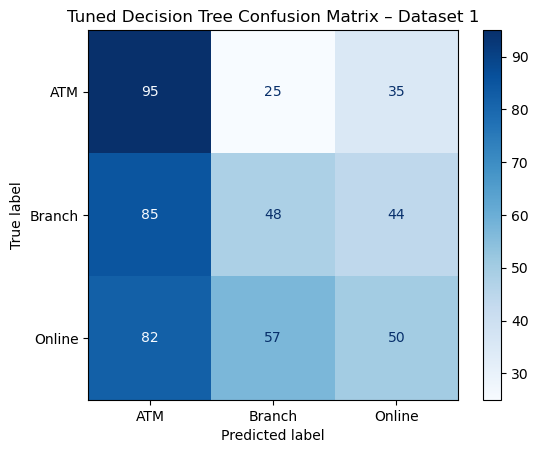

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_test_predictions,
    cmap="Blues"
)

plt.title("Tuned Decision Tree Confusion Matrix – Dataset 1")
plt.show()

In [58]:
print(
    classification_report(
        y_test,
        tuned_test_predictions,
        digits=3
    )
)

              precision    recall  f1-score   support

         ATM      0.363     0.613     0.456       155
      Branch      0.369     0.271     0.313       177
      Online      0.388     0.265     0.314       189

    accuracy                          0.370       521
   macro avg      0.373     0.383     0.361       521
weighted avg      0.374     0.370     0.356       521



In [59]:
tuned_preprocessor = best_tree_model.named_steps["preprocessor"]

tuned_feature_names = tuned_preprocessor.get_feature_names_out()

tuned_feature_importance = pd.DataFrame({
    "Feature": tuned_feature_names,
    "Importance": best_classifier.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

tuned_feature_importance.head(10)

,Feature,Importance
11,numerical__TransactionAmount,0.316737
13,numerical__AccountBalance,0.217236
0,categorical__TransactionType_Credit,0.206983
12,numerical__CustomerAge,0.119404
7,categorical__DayOfWeek_Monday,0.050680
14,numerical__Month,0.044914
3,categorical__CustomerOccupation_Engineer,0.022551
10,categorical__DayOfWeek_Wednesday,0.016360
15,numerical__Hour,0.005135
1,categorical__TransactionType_Debit,0.000000


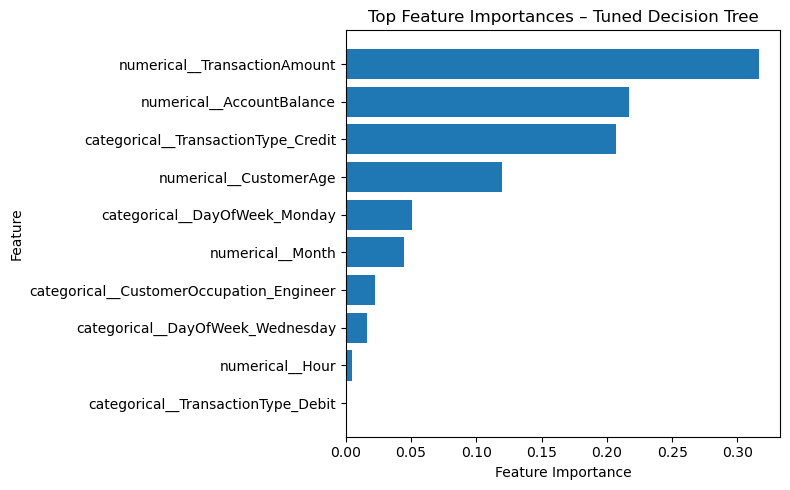

In [60]:
top_tuned_features = tuned_feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_tuned_features["Feature"],
    top_tuned_features["Importance"]
)

plt.title("Top Feature Importances – Tuned Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Observation:
- TransactionAmount is the most influential feature in the tuned Decision Tree, followed by AccountBalance, Credit TransactionType and CustomerAge.
- TransactionType becomes substantially more important after tuning, which is consistent with the earlier EDA showing differences in channel usage between Debit and Credit transactions.
- Temporal features such as DayOfWeek, Month and Hour contribute less to the tuned model.
- These feature importances describe how the Decision Tree makes its predictions and should not be interpreted as evidence that these variables cause customers to choose particular banking channels.

# Dataset 2: Personal Finance Transactions

## 11. Initial Inspection and Data Quality

In [61]:
df2 = pd.read_csv("Datasets/Personal_Finance_Dataset.csv")

df2.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [62]:
print("Shape:", df2.shape)
print("\nColumns:")
print(df2.columns.tolist())

print("\nMissing values:")
print(df2.isnull().sum())

print("\nDuplicate rows:", df2.duplicated().sum())

print("\nUnique values:")
print(df2.nunique())

Shape: (1500, 5)

Columns:
['Date', 'Transaction Description', 'Category', 'Amount', 'Type']

Missing values:
Date                       0
Transaction Description    0
Category                   0
Amount                     0
Type                       0
dtype: int64

Duplicate rows: 0

Unique values:
Date                       1025
Transaction Description    1500
Category                     10
Amount                     1492
Type                          2
dtype: int64


Observation:
- Dataset 2 contains 1,500 transactions and five variables, with no missing values or duplicate rows.
- Category contains 10 classes and is the proposed target variable.
- All Transaction Description values are unique, so the text field requires careful consideration before modelling.

## 12. Target Variable and Leakage Assessment

In [63]:
category_counts = df2["Category"].value_counts()

print(category_counts)

print("\nCategory percentages:")
print((df2["Category"].value_counts(normalize=True) * 100).round(2))

Category
Rent                165
Travel              160
Utilities           157
Health & Fitness    152
Shopping            150
Food & Drink        149
Salary              146
Entertainment       143
Investment          142
Other               136
Name: count, dtype: int64

Category percentages:
Category
Rent                11.00
Travel              10.67
Utilities           10.47
Health & Fitness    10.13
Shopping            10.00
Food & Drink         9.93
Salary               9.73
Entertainment        9.53
Investment           9.47
Other                9.07
Name: proportion, dtype: float64


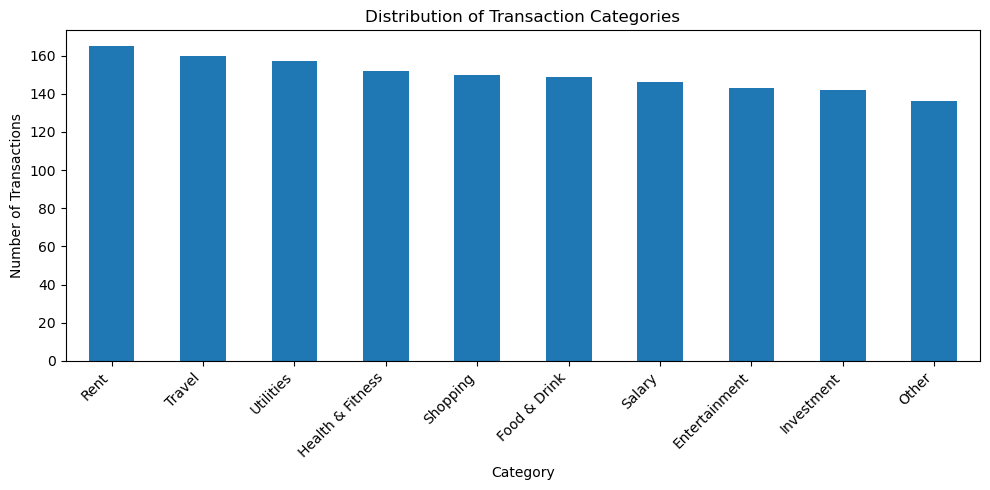

In [64]:
plt.figure(figsize=(10, 5))

df2["Category"].value_counts().plot(kind="bar")

plt.title("Distribution of Transaction Categories")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Observation:
- The 10 Category classes are distributed relatively evenly, with no severe class imbalance.
- This makes Category a more suitable multiclass target than a highly skewed alternative.
- Evaluation should still consider class-level performance rather than relying only on overall accuracy.

In [65]:
pd.crosstab(
    df2["Category"],
    df2["Type"]
)

Type,Expense,Income
Category,,
Entertainment,143,0
Food & Drink,149,0
Health & Fitness,152,0
Investment,0,142
Other,0,136
Rent,165,0
Salary,146,0
Shopping,150,0
Travel,160,0


Observation:
- Type is strongly determined by Category: Investment and Other are exclusively labelled Income, while all remaining categories are labelled Expense.
- Using Type to predict Category would therefore introduce substantial target leakage.
- Type will be excluded from the Category prediction model.

Additional data-quality note:
- Salary transactions are labelled as Expense in this dataset, which is unusual from a personal-finance perspective.
- The labels were retained as provided by the source, but this inconsistency should be considered when interpreting the dataset and its real-world applicability.

## 13. Feature Engineering

In [66]:
df2_work = df2.copy()

df2_work["Date"] = pd.to_datetime(df2_work["Date"])

print("Earliest date:", df2_work["Date"].min())
print("Latest date:", df2_work["Date"].max())

Earliest date: 2020-01-02 00:00:00
Latest date: 2024-12-29 00:00:00


In [67]:
df2_work["Year"] = df2_work["Date"].dt.year
df2_work["Month"] = df2_work["Date"].dt.month
df2_work["DayOfWeek"] = df2_work["Date"].dt.day_name()
df2_work["DayOfMonth"] = df2_work["Date"].dt.day
df2_work["IsWeekend"] = df2_work["Date"].dt.dayofweek >= 5

In [68]:
print("Years:")
print(df2_work["Year"].value_counts().sort_index())

print("\nDay of week:")
print(df2_work["DayOfWeek"].value_counts())

print("\nWeekend:")
print(df2_work["IsWeekend"].value_counts())

Years:
Year
2020    290
2021    280
2022    303
2023    323
2024    304
Name: count, dtype: int64

Day of week:
DayOfWeek
Friday       229
Sunday       226
Monday       220
Wednesday    217
Thursday     213
Saturday     199
Tuesday      196
Name: count, dtype: int64

Weekend:
IsWeekend
False    1075
True      425
Name: count, dtype: int64


In [69]:
df2_work["Amount"].describe()

count    1500.000000
mean     1307.520913
std       982.283361
min        14.370000
25%       629.340000
50%      1156.285000
75%      1712.932500
max      4996.000000
Name: Amount, dtype: float64

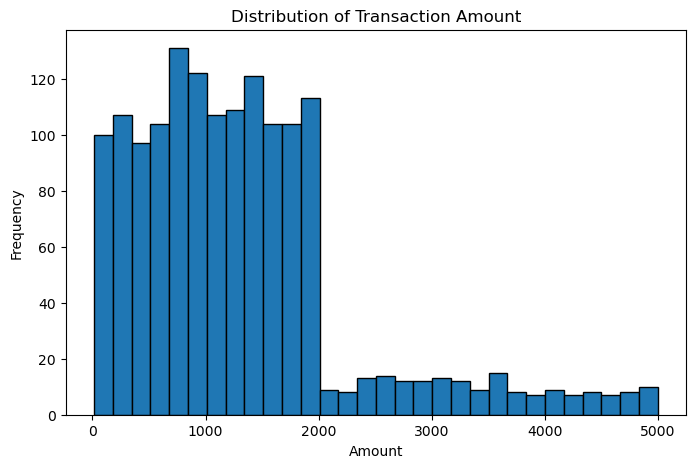

In [70]:
plt.figure(figsize=(8, 5))

plt.hist(
    df2_work["Amount"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

<Figure size 1200x600 with 0 Axes>

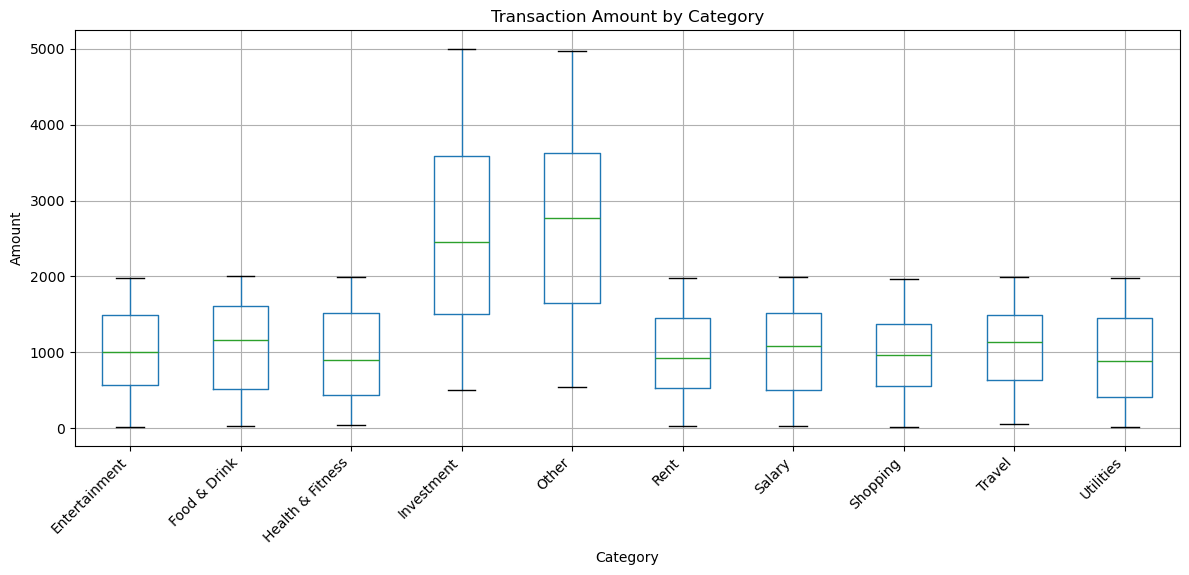

In [71]:
plt.figure(figsize=(12, 6))

df2_work.boxplot(
    column="Amount",
    by="Category",
    figsize=(12, 6)
)

plt.title("Transaction Amount by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Observation:
- Investment and Other generally have higher transaction amounts than the remaining categories.
- Most expense categories show substantial overlap in their Amount distributions.
- Amount therefore provides some Category signal, particularly for Investment and Other, but is unlikely to distinguish all 10 categories reliably by itself.

In [72]:
import numpy as np

df2_work["LogAmount"] = np.log1p(df2_work["Amount"])

df2_work[["Amount", "LogAmount"]].describe()

,Amount,LogAmount
count,1500.000000,1500.000000
mean,1307.520913,6.844013
std,982.283361,0.940430
min,14.370000,2.732418
25%,629.340000,6.446258
50%,1156.285000,7.053832
75%,1712.932500,7.446546
max,4996.000000,8.516593


### Decision 5: Dataset 2 Type variable

Issue:
Type is closely determined by Category and would reveal substantial information about the target.

Decision:
Exclude Type from the Category prediction model to avoid target leakage.

---

### Decision 6: Transaction Description

Issue:
Every Transaction Description is unique, creating a high-cardinality free-text feature that would require a separate NLP/text-modelling approach.

Decision:
Exclude Transaction Description from the initial model and focus on structured financial and temporal features.

In [73]:
features_d2 = [
    "Amount",
    "LogAmount",
    "Year",
    "Month",
    "DayOfWeek",
    "DayOfMonth",
    "IsWeekend"
]

target_d2 = "Category"

X2 = df2_work[features_d2]
y2 = df2_work[target_d2]

print("Dataset 2 features:")
print(features_d2)

print("\nTarget:", target_d2)

print("\nX shape:", X2.shape)
print("y shape:", y2.shape)

Dataset 2 features:
['Amount', 'LogAmount', 'Year', 'Month', 'DayOfWeek', 'DayOfMonth', 'IsWeekend']

Target: Category

X shape: (1500, 7)
y shape: (1500,)


Observation:
- The preliminary Dataset 2 model uses transaction amount and calendar-derived features to predict Category.
- Type was excluded because of target leakage, while Transaction Description was excluded because every value is unique and would require a separate text-modelling approach.
- This setup tests how much transaction category information can be recovered from structured amount and timing information alone.

## 14. Data Preparation and Baseline Model

In [74]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)

print("Training rows:", len(X2_train))
print("Test rows:", len(X2_test))

print("\nTraining category distribution (%):")
print((y2_train.value_counts(normalize=True) * 100).round(2))

print("\nTest category distribution (%):")
print((y2_test.value_counts(normalize=True) * 100).round(2))

Training rows: 1200
Test rows: 300

Training category distribution (%):
Category
Rent                11.00
Travel              10.67
Utilities           10.50
Health & Fitness    10.08
Shopping            10.00
Food & Drink         9.92
Salary               9.75
Investment           9.50
Entertainment        9.50
Other                9.08
Name: proportion, dtype: float64

Test category distribution (%):
Category
Rent                11.00
Travel              10.67
Health & Fitness    10.33
Utilities           10.33
Shopping            10.00
Food & Drink        10.00
Salary               9.67
Entertainment        9.67
Investment           9.33
Other                9.00
Name: proportion, dtype: float64


Observation:
- An 80/20 stratified train/test split was used so that the relative distribution of the 10 transaction categories remained similar in both subsets.
- The test set was kept separate for final model evaluation.

In [75]:
numeric_features_d2 = [
    "Amount",
    "LogAmount",
    "Year",
    "Month",
    "DayOfMonth"
]

categorical_features_d2 = [
    "DayOfWeek",
    "IsWeekend"
]

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_d2 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_d2
        ),
        (
            "numerical",
            "passthrough",
            numeric_features_d2
        )
    ]
)

In [77]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

baseline_d2 = Pipeline([
    ("preprocessor", preprocessor_d2),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline_d2.fit(X2_train, y2_train)

baseline_d2_predictions = baseline_d2.predict(X2_test)

baseline_d2_accuracy = accuracy_score(
    y2_test,
    baseline_d2_predictions
)

baseline_d2_f1 = f1_score(
    y2_test,
    baseline_d2_predictions,
    average="macro"
)

print("Dataset 2 Baseline Accuracy:",
      round(baseline_d2_accuracy, 3))

print("Dataset 2 Baseline Macro F1:",
      round(baseline_d2_f1, 3))

Dataset 2 Baseline Accuracy: 0.11
Dataset 2 Baseline Macro F1: 0.02


Observation:
- A most-frequent-class Dummy Classifier was used as a baseline.
- This provides a minimum reference point for determining whether the machine learning model learns useful Category patterns beyond simply predicting the most common class.

## 15. Random Forest Classification

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

rf_model = Pipeline([
    ("preprocessor", clone(preprocessor_d2)),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(X2_train, y2_train)

rf_train_predictions = rf_model.predict(X2_train)
rf_test_predictions = rf_model.predict(X2_test)

In [79]:
rf_train_accuracy = accuracy_score(
    y2_train,
    rf_train_predictions
)

rf_test_accuracy = accuracy_score(
    y2_test,
    rf_test_predictions
)

rf_train_f1 = f1_score(
    y2_train,
    rf_train_predictions,
    average="macro"
)

rf_test_f1 = f1_score(
    y2_test,
    rf_test_predictions,
    average="macro"
)

print("Baseline Accuracy:",
      round(baseline_d2_accuracy, 3))
print("Baseline Macro F1:",
      round(baseline_d2_f1, 3))

print("\nRandom Forest Training Accuracy:",
      round(rf_train_accuracy, 3))
print("Random Forest Test Accuracy:",
      round(rf_test_accuracy, 3))

print("\nRandom Forest Training Macro F1:",
      round(rf_train_f1, 3))
print("Random Forest Test Macro F1:",
      round(rf_test_f1, 3))

Baseline Accuracy: 0.11
Baseline Macro F1: 0.02

Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.133

Random Forest Training Macro F1: 1.0
Random Forest Test Macro F1: 0.141


Observation:
- The Random Forest achieved a test accuracy of 0.133 and a Macro F1-score of 0.141, compared with the baseline accuracy of 0.110 and baseline Macro F1-score of 0.020.
- Training accuracy and Macro F1 were both 1.000, while test performance was substantially lower.
- This indicates severe overfitting in the unrestricted Random Forest.
- Although test accuracy improves only slightly over the majority-class baseline, the increase in Macro F1 suggests that the model captures some non-trivial information across multiple transaction categories rather than predicting only the most common class.

In [80]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y2_test,
        rf_test_predictions,
        digits=3
    )
)

                  precision    recall  f1-score   support

   Entertainment      0.086     0.103     0.094        29
    Food & Drink      0.080     0.067     0.073        30
Health & Fitness      0.032     0.032     0.032        31
      Investment      0.286     0.214     0.245        28
           Other      0.385     0.370     0.377        27
            Rent      0.054     0.061     0.057        33
          Salary      0.179     0.172     0.175        29
        Shopping      0.121     0.133     0.127        30
          Travel      0.057     0.062     0.060        32
       Utilities      0.172     0.161     0.167        31

        accuracy                          0.133       300
       macro avg      0.145     0.138     0.141       300
    weighted avg      0.140     0.133     0.136       300



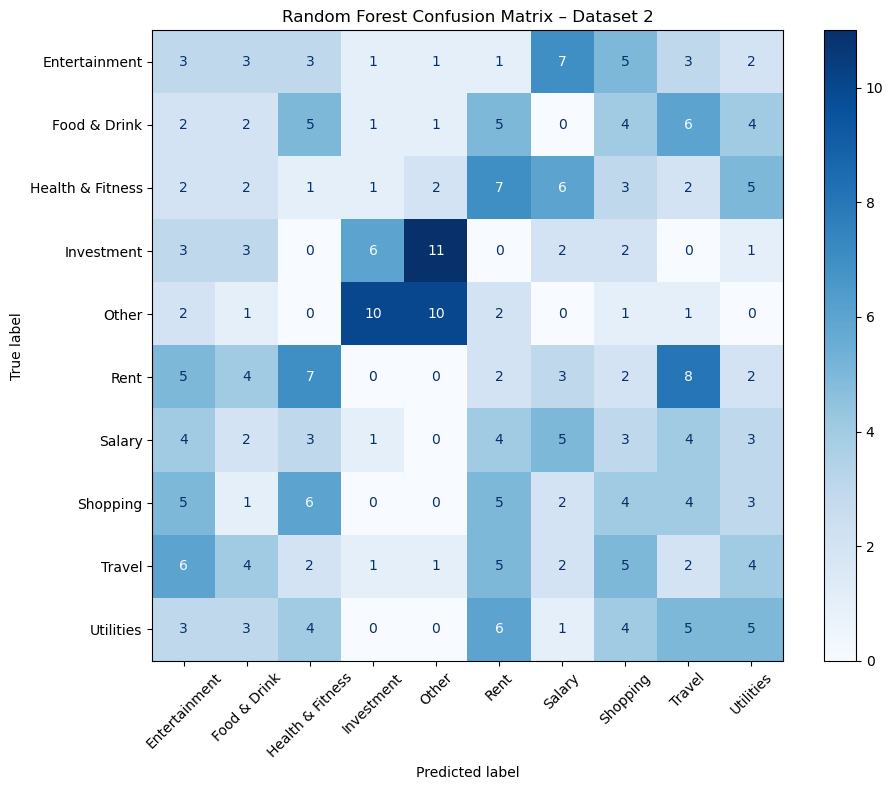

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y2_test,
    rf_test_predictions,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

plt.title("Random Forest Confusion Matrix – Dataset 2")
plt.tight_layout()
plt.show()

Observation:
- The model performs best for the Other category, with an F1-score of 0.377 and recall of 0.370, followed by Investment with an F1-score of 0.245.
- The greatest confusion occurs between Investment and Other, with many transactions from each category being predicted as the other.
- This is consistent with the earlier EDA showing that both Investment and Other tend to have relatively high transaction amounts.
- Most other spending categories remain difficult to distinguish using Amount and calendar-derived features alone.

In [82]:
rf_classifier = rf_model.named_steps["classifier"]

rf_preprocessor = rf_model.named_steps["preprocessor"]

rf_feature_names = rf_preprocessor.get_feature_names_out()

rf_feature_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_classifier.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

rf_feature_importance.head(10)

,Feature,Importance
9,numerical__Amount,0.236572
10,numerical__LogAmount,0.236410
13,numerical__DayOfMonth,0.178269
12,numerical__Month,0.141979
11,numerical__Year,0.098208
1,categorical__DayOfWeek_Monday,0.015710
4,categorical__DayOfWeek_Thursday,0.015588
5,categorical__DayOfWeek_Tuesday,0.015327
6,categorical__DayOfWeek_Wednesday,0.014443
0,categorical__DayOfWeek_Friday,0.014419


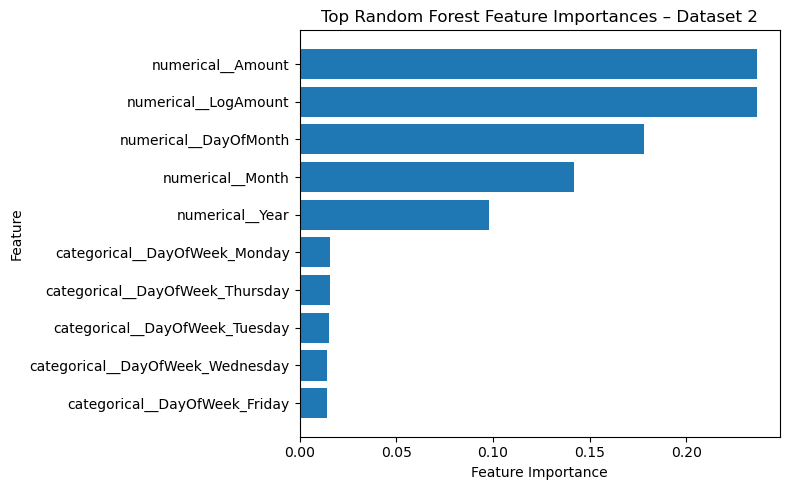

In [83]:
top_rf_features = rf_feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)

plt.title("Top Random Forest Feature Importances – Dataset 2")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Observation:
- The Random Forest relies most heavily on transaction amount information, with Amount and LogAmount receiving the highest feature importance, followed by DayOfMonth, Month and Year.
- This is consistent with the earlier EDA showing that transaction amount provides some Category signal, particularly for Investment and Other.
- However, Amount and LogAmount represent the same underlying financial variable, so their separate importance values should not be interpreted as independent sources of information.
- Feature importance reflects predictive use within the model and should not be interpreted as evidence of causation.

### Evaluation metric rationale

Accuracy is useful because the 10 Category classes are relatively balanced and provides an intuitive measure of overall classification performance.

Macro F1 is also used because it gives equal importance to each transaction category and helps identify whether strong performance on some categories hides poor performance on others.

The confusion matrix provides category-level insight into which spending classes are most frequently confused.

## 16. Random Forest Tuning and Final Evaluation

In [84]:
final_features_d2 = [
    "Amount",
    "Year",
    "Month",
    "DayOfWeek",
    "DayOfMonth",
    "IsWeekend"
]

X2_final = df2_work[final_features_d2]

X2_train_final = X2_final.loc[X2_train.index]
X2_test_final = X2_final.loc[X2_test.index]

print("Final Dataset 2 features:")
print(final_features_d2)

Final Dataset 2 features:
['Amount', 'Year', 'Month', 'DayOfWeek', 'DayOfMonth', 'IsWeekend']


Observation:
- LogAmount was explored in the initial Random Forest but represents the same underlying transaction-value information as Amount.
- To reduce redundant predictors and improve interpretability, the final model retains Amount and removes LogAmount.

In [85]:
numeric_features_d2_final = [
    "Amount",
    "Year",
    "Month",
    "DayOfMonth"
]

categorical_features_d2_final = [
    "DayOfWeek",
    "IsWeekend"
]

preprocessor_d2_final = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_d2_final
        ),
        (
            "numerical",
            "passthrough",
            numeric_features_d2_final
        )
    ]
)

In [86]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

rf_tuning_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor_d2_final)),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, 15, None],
    "classifier__min_samples_split": [5, 10, 20],
    "classifier__min_samples_leaf": [2, 5, 10],
    "classifier__max_features": ["sqrt"]
}

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=stratified_cv,
    n_jobs=-1
)

rf_grid_search.fit(
    X2_train_final,
    y2_train
)

print("Best parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(round(rf_grid_search.best_score_, 3))

Best parameters:
{'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Best cross-validation Macro F1:
0.182


Observation:
- Stratified cross-validation was used to tune the Random Forest while maintaining similar Category proportions across validation folds.
- The best-performing configuration used 100 trees, a maximum depth of 15, square-root feature sampling, a minimum of 10 samples per leaf, and a minimum of 5 samples required to split a node.
- The best cross-validation Macro F1-score was 0.182.
- Model complexity was restricted to investigate whether the severe overfitting observed in the unrestricted Random Forest could be reduced.

In [87]:
best_rf_model = rf_grid_search.best_estimator_

tuned_rf_train_predictions = best_rf_model.predict(
    X2_train_final
)

tuned_rf_test_predictions = best_rf_model.predict(
    X2_test_final
)

tuned_rf_train_accuracy = accuracy_score(
    y2_train,
    tuned_rf_train_predictions
)

tuned_rf_test_accuracy = accuracy_score(
    y2_test,
    tuned_rf_test_predictions
)

tuned_rf_train_f1 = f1_score(
    y2_train,
    tuned_rf_train_predictions,
    average="macro"
)

tuned_rf_test_f1 = f1_score(
    y2_test,
    tuned_rf_test_predictions,
    average="macro"
)

print("Baseline")
print("Accuracy:", round(baseline_d2_accuracy, 3))
print("Macro F1:", round(baseline_d2_f1, 3))

print("\nInitial Random Forest")
print("Training Accuracy:", round(rf_train_accuracy, 3))
print("Test Accuracy:", round(rf_test_accuracy, 3))
print("Training Macro F1:", round(rf_train_f1, 3))
print("Test Macro F1:", round(rf_test_f1, 3))

print("\nTuned Random Forest")
print("Training Accuracy:", round(tuned_rf_train_accuracy, 3))
print("Test Accuracy:", round(tuned_rf_test_accuracy, 3))
print("Training Macro F1:", round(tuned_rf_train_f1, 3))
print("Test Macro F1:", round(tuned_rf_test_f1, 3))

Baseline
Accuracy: 0.11
Macro F1: 0.02

Initial Random Forest
Training Accuracy: 1.0
Test Accuracy: 0.133
Training Macro F1: 1.0
Test Macro F1: 0.141

Tuned Random Forest
Training Accuracy: 0.523
Test Accuracy: 0.15
Training Macro F1: 0.521
Test Macro F1: 0.164


Observation:
- The tuned Random Forest achieved a test accuracy of 0.150 and a Macro F1-score of 0.164.
- Compared with the unrestricted Random Forest, training accuracy decreased from 1.000 to 0.523 and training Macro F1 decreased from 1.000 to 0.521, while test accuracy improved from 0.133 to 0.150 and test Macro F1 improved from 0.141 to 0.164.
- This indicates that tuning substantially reduced the extreme overfitting of the original model, although a noticeable gap between training and test performance remains.
- Compared with the baseline accuracy of 0.110 and Macro F1 of 0.020, the tuned model captures limited but non-trivial predictive information about transaction Category.

In [88]:
print(
    classification_report(
        y2_test,
        tuned_rf_test_predictions,
        digits=3
    )
)

                  precision    recall  f1-score   support

   Entertainment      0.167     0.172     0.169        29
    Food & Drink      0.077     0.033     0.047        30
Health & Fitness      0.042     0.032     0.036        31
      Investment      0.474     0.321     0.383        28
           Other      0.556     0.370     0.444        27
            Rent      0.044     0.061     0.051        33
          Salary      0.061     0.069     0.065        29
        Shopping      0.211     0.267     0.235        30
          Travel      0.043     0.062     0.051        32
       Utilities      0.147     0.161     0.154        31

        accuracy                          0.150       300
       macro avg      0.182     0.155     0.164       300
    weighted avg      0.174     0.150     0.157       300



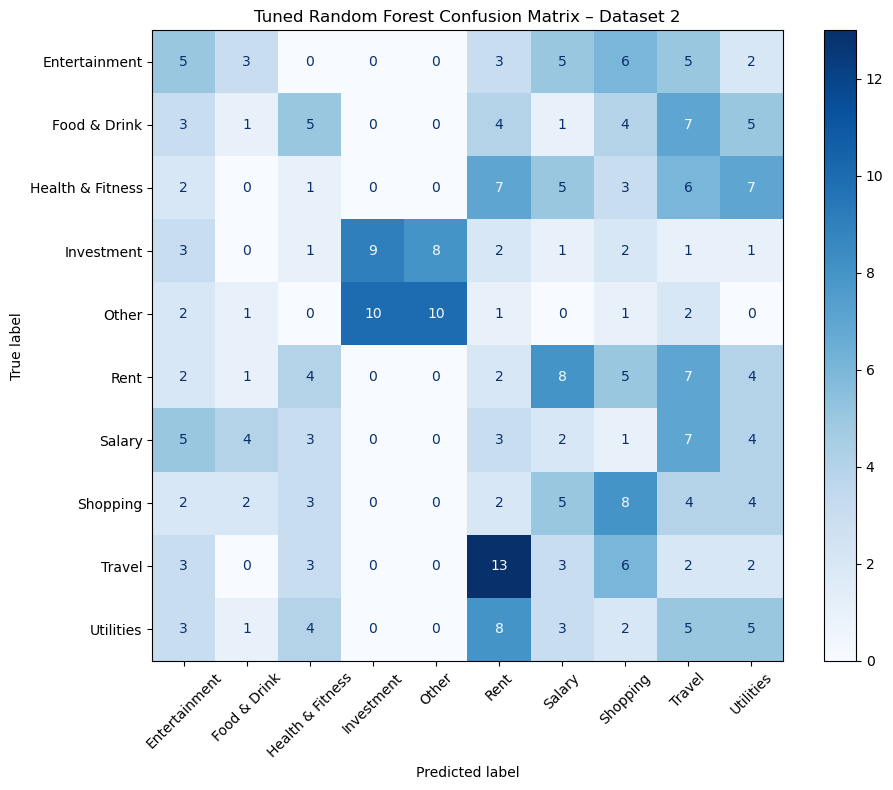

In [89]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y2_test,
    tuned_rf_test_predictions,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

plt.title("Tuned Random Forest Confusion Matrix – Dataset 2")
plt.tight_layout()
plt.show()

Observation:
- The tuned model performs best for Other, with an F1-score of 0.444, followed by Investment with an F1-score of 0.383.
- The largest single misclassification occurs when Travel transactions are predicted as Rent, while Investment and Other also remain strongly confused with one another.
- The relatively better performance for Investment and Other is consistent with the earlier EDA showing that these categories tend to have higher transaction amounts.
- Overall, most transaction categories remain difficult to distinguish using transaction amount and calendar-derived features alone.

In [90]:
best_rf_classifier = best_rf_model.named_steps["classifier"]

best_rf_preprocessor = best_rf_model.named_steps["preprocessor"]

best_rf_feature_names = (
    best_rf_preprocessor.get_feature_names_out()
)

final_rf_importance = pd.DataFrame({
    "Feature": best_rf_feature_names,
    "Importance": best_rf_classifier.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

final_rf_importance.head(10)

,Feature,Importance
9,numerical__Amount,0.479078
12,numerical__DayOfMonth,0.154297
11,numerical__Month,0.135242
10,numerical__Year,0.103541
0,categorical__DayOfWeek_Friday,0.019255
6,categorical__DayOfWeek_Wednesday,0.015485
5,categorical__DayOfWeek_Tuesday,0.014461
7,categorical__IsWeekend_False,0.014336
1,categorical__DayOfWeek_Monday,0.013764
4,categorical__DayOfWeek_Thursday,0.013263


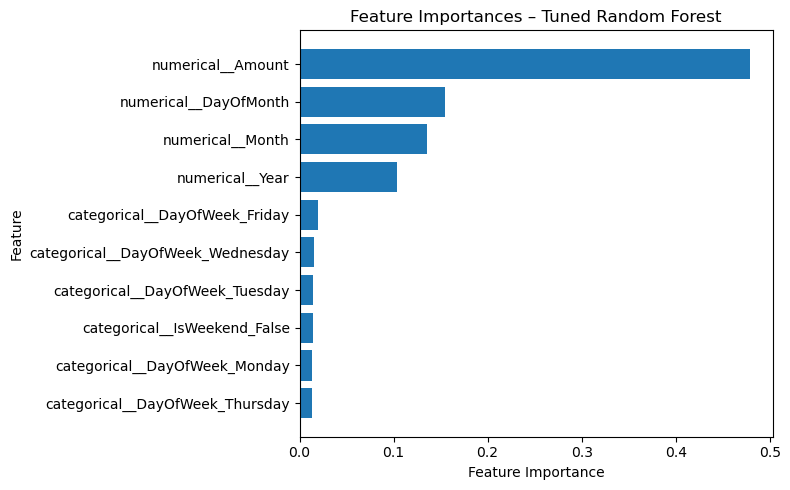

In [91]:
top_final_rf_features = final_rf_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_final_rf_features["Feature"],
    top_final_rf_features["Importance"]
)

plt.title("Feature Importances – Tuned Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Observation:
- The tuned Random Forest relies most heavily on Transaction Amount, which accounts for substantially more feature importance than any other individual predictor.
- DayOfMonth, Month and Year provide smaller but noticeable contributions, while individual DayOfWeek and weekend indicators contribute relatively little.
- This is consistent with the earlier EDA showing that Amount contains useful Category information, particularly for Investment and Other, but that calendar information alone is insufficient to reliably distinguish most spending categories.
- Feature importance reflects predictive use within the model and does not establish causation.

# 17. Cross-Dataset Comparison and Overall Findings

In [92]:
comparison_results = pd.DataFrame({
    "Dataset": [
        "Dataset 1 - Bank Transactions",
        "Dataset 2 - Personal Finance"
    ],
    "Target": [
        "Channel",
        "Category"
    ],
    "Model": [
        "Tuned Decision Tree",
        "Tuned Random Forest"
    ],
    "Baseline Accuracy": [
        baseline_accuracy,
        baseline_d2_accuracy
    ],
    "Model Accuracy": [
        tuned_test_accuracy,
        tuned_rf_test_accuracy
    ],
    "Baseline Macro F1": [
        baseline_f1,
        baseline_d2_f1
    ],
    "Model Macro F1": [
        tuned_test_f1,
        tuned_rf_test_f1
    ]
})

comparison_results.round(3)

,Dataset,Target,Model,Baseline Accuracy,Model Accuracy,Baseline Macro F1,Model Macro F1
0,Dataset 1 - Bank Transactions,Channel,Tuned Decision Tree,0.34,0.37,0.169,0.361
1,Dataset 2 - Personal Finance,Category,Tuned Random Forest,0.11,0.15,0.020,0.164


### Model comparison observations

- Both tuned models outperform their respective majority-class baselines, although overall predictive accuracy remains modest.
- Dataset 1 improves from 0.340 to 0.370 accuracy, while Macro F1 increases from 0.169 to 0.361.
- Dataset 2 improves from 0.110 to 0.150 accuracy, while Macro F1 increases from 0.020 to 0.164.
- The Macro F1 improvements are particularly important because the baseline classifiers predict only the most frequent class, whereas the machine learning models recover some information across multiple classes.
- Neither dataset supports highly reliable prediction from the selected structured features alone.

### Cross-dataset insight comparison

| Aspect | Dataset 1 | Dataset 2 |
|---|---|---|
| Business perspective | Banking channel behaviour | Spending-category behaviour |
| Target | ATM / Branch / Online | 10 transaction categories |
| Strongest signals | TransactionAmount, AccountBalance, TransactionType, CustomerAge | Amount, DayOfMonth, Month, Year |
| Stronger predictions | ATM | Other and Investment |
| Main limitation | Branch and Online difficult to distinguish | Most expense categories overlap heavily |
| Overall finding | Limited but non-trivial channel signal | Limited but non-trivial category signal |

### Complementary vs contradictory findings

Working interpretation:
- The two datasets appear to provide complementary rather than contradictory insights because they represent different dimensions of digital banking behaviour.
- Dataset 1 examines how transactions are conducted through different banking channels, while Dataset 2 examines what types of financial activities transactions represent.
- Both models find limited but non-trivial predictive signal, suggesting that structured transaction, customer and temporal variables can provide useful information but are insufficient on their own for highly reliable prediction.
- Richer behavioural, merchant, contextual or transaction-description information may be needed to support stronger personalisation and automated financial-wellbeing services.

## 18. Analysis Limitations

### Dataset 1
- No fraud label was available despite the initial fraud-related interpretation of the dataset.
- PreviousTransactionDate was inconsistent because all recorded previous dates occurred after the corresponding TransactionDate.
- Transaction times covered only a limited set of hours and no weekend transactions were present.
- Several fields were high-cardinality identifiers and were excluded to reduce memorisation risk.
- Channel prediction remained difficult despite tuning.

### Dataset 2
- Type was strongly determined by Category and was excluded because of target leakage.
- Salary was unusually labelled as Expense.
- Transaction Description was unique for every record and was excluded from the structured model.
- Amount provided stronger signal for Investment and Other, while most expense categories overlapped substantially.
- Calendar and Amount features alone produced limited Category prediction performance.

### General
- The datasets represent different populations and cannot be linked at an individual-customer level.
- Therefore, conclusions can only compare patterns across the two datasets rather than claim a direct relationship between an individual's channel behaviour and spending behaviour.

## 19. Overall Working Takeaway

- Dataset 1 showed that the available transaction and customer features provide some useful information about banking-channel behaviour, especially for identifying ATM transactions. However, Branch and Online transactions were harder to distinguish, and the tuned Decision Tree only improved modestly over the baseline despite a meaningful improvement in Macro F1.

- Dataset 2 showed that transaction amount provides some useful information for spending categorisation, particularly for Investment and Other transactions because these generally involved higher amounts. However, most of the remaining categories overlap considerably, so Amount and date-derived features alone were not sufficient for reliable categorisation.

- Taken together, the results suggest that structured transaction, temporal and customer information provides limited but non-trivial predictive signal. A real banking personalisation system would likely require richer information such as merchant details, transaction descriptions, location, longer customer histories and broader behavioural context to produce more reliable personalised insights.